# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muhammad Aldyn Ismail Putra
- **Email:** cdcc525d6y0081@student.devacademy.id
- **ID Dicoding:** CDCC525D6Y0081

## Menentukan Pertanyaan Bisnis

- Bagaimana pola jumlah penyewaan sepeda berdasarkan waktu (jam, hari kerja vs akhir pekan, dan musim)?
- Bagaimana pengaruh kondisi cuaca (weathersit, suhu, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [11]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print("Data per jam:", hour_df.shape)
print("Data per hari:", day_df.shape)

Data per jam: (17379, 17)
Data per hari: (731, 16)


**Insight:**
- dataset perjam (hour.csv) dan per hari (day.csv) berhasil dimuat
- Dataset per jam (hour_df) memiliki 17.379 baris dan 17 kolom sedangkan dataset per hari (day_df) memiliki 731 baris dan 16 kolom

### Assessing Data

In [12]:
# cek missing value
print("Missing values - hour dataset")
hour_df.isna().sum()

print("Missing values - day dataset")
day_df.isna().sum()

#cek duplikasi data
print("Duplicate data (day):", day_df.duplicated().sum())
print("Duplicate data (hour):", hour_df.duplicated().sum())

day_df.dtypes
hour_df.dtypes



Missing values - hour dataset
Missing values - day dataset
Duplicate data (day): 0
Duplicate data (hour): 0


,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


**Insight:**
- Baik pada dataset hour maupun day tidak ditemukan missing values, sehingga data dapat langsung digunakan untuk analisis tanpa perlu proses imputasi atau penghapusan data kosong.
- Jumlah duplicate pada kedua dataset adalah 0, yang berarti setiap baris merepresentasikan observasi unik (jam atau hari tertentu), sehingga kualitas data dari sisi redundansi sudah baik.

### Cleaning Data

In [13]:

# Convert kolom tanggal ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Ubah tipe data kategorikal agar lebih jelas
categorical_cols_day = ['season', 'yr', 'mnth', 'holiday',
                        'weekday', 'workingday', 'weathersit']

categorical_cols_hour = ['season', 'yr', 'mnth', 'hr', 'holiday',
                         'weekday', 'workingday', 'weathersit']

day_df[categorical_cols_day] = day_df[categorical_cols_day].astype('category')
hour_df[categorical_cols_hour] = hour_df[categorical_cols_hour].astype('category')

# Rename kolom agar lebih readable
day_df.rename(columns={'cnt': 'total_count'}, inplace=True)
hour_df.rename(columns={'cnt': 'total_count'}, inplace=True)

# Cek hasil setelah cleaning
print(day_df.info())

print(hour_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   instant      731 non-null    int64         
 1   dteday       731 non-null    datetime64[ns]
 2   season       731 non-null    category      
 3   yr           731 non-null    category      
 4   mnth         731 non-null    category      
 5   holiday      731 non-null    category      
 6   weekday      731 non-null    category      
 7   workingday   731 non-null    category      
 8   weathersit   731 non-null    category      
 9   temp         731 non-null    float64       
 10  atemp        731 non-null    float64       
 11  hum          731 non-null    float64       
 12  windspeed    731 non-null    float64       
 13  casual       731 non-null    int64         
 14  registered   731 non-null    int64         
 15  total_count  731 non-null    int64         
dtypes: categ

**Insight:**
- pengubahan tipe data (dteday) mejadi datetime dan mengubah tipe data dari kolom 'season', 'yr', 'mnth', 'holiday',
                        'weekday', 'workingday', 'weathersit' menjadi kategorikal
- mengubah nama kolom cnt menjadi total_count agar mudah untuk dibaca

## Exploratory Data Analysis (EDA)

### Explore data

In [14]:
# EDA pertanyaan 1 pola jam
hourly_pattern = hour_df.groupby('hr')['total_count'].mean().reset_index()
hourly_pattern.columns = ['hour', 'average_rentals']

print("Rata-rata Penyewaan per Jam:")
display(hourly_pattern.head())

# hari kerja vs akhir pekan
workday_vs_weekend = hour_df.groupby('workingday')['total_count'].mean().reset_index()
workday_vs_weekend['workingday'] = workday_vs_weekend['workingday'].map({0: 'Weekend/Holiday', 1: 'Working Day'})
workday_vs_weekend.columns = ['day_type', 'average_rentals']

print("\nPerbandingan Working Day vs Weekend:")
display(workday_vs_weekend)

# pola bedasarkan musim
season_pattern = hour_df.groupby('season')['total_count'].mean().reset_index()
season_pattern['season'] = season_pattern['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})
season_pattern.columns = ['season', 'average_rentals']

print("\nRata-rata Penyewaan Berdasarkan Musim:")
display(season_pattern)

#EDA pertanyaan 2
#pengaruh cuaca
weather_effect = hour_df.groupby('weathersit')['total_count'].mean().reset_index()
weather_effect.columns = ['weather_condition', 'average_rentals']

print("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca:")
display(weather_effect)

#Korelasi Faktor Cuaca terhadap Jumlah Penyewaan
weather_corr = hour_df[['temp', 'atemp', 'hum', 'windspeed', 'total_count']].corr()

print("\nKorelasi Variabel Cuaca terhadap Jumlah Penyewaan:")
display(weather_corr['total_count'].sort_values(ascending=False))

Rata-rata Penyewaan per Jam:


/tmp/ipykernel_4783/2302948678.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_pattern = hour_df.groupby('hr')['total_count'].mean().reset_index()


,hour,average_rentals
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941



Perbandingan Working Day vs Weekend:


/tmp/ipykernel_4783/2302948678.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  workday_vs_weekend = hour_df.groupby('workingday')['total_count'].mean().reset_index()


...

Rata-rata Penyewaan Berdasarkan Kondisi Cuaca:


/tmp/ipykernel_4783/2302948678.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_effect = hour_df.groupby('weathersit')['total_count'].mean().reset_index()


,weather_condition,average_rentals
0,1,204.869272
1,2,175.165493
2,3,111.579281
3,4,74.333333



Korelasi Variabel Cuaca terhadap Jumlah Penyewaan:


,total_count
total_count,1.000000
temp,0.404772
atemp,0.400929
windspeed,0.093234
hum,-0.322911


**Insight:**
- Permintaan penyewaan sepeda menunjukkan pola waktu yang jelas, dengan aktivitas rendah pada dini hari dan lebih tinggi pada jam aktif, terutama hari kerja.
- Rata-rata penyewaan lebih tinggi pada working day dibandingkan akhir pekan, yang menunjukkan bahwa sepeda lebih banyak digunakan untuk kebutuhan transportasi rutin.
- Musim memiliki pengaruh signifikan, di mana Fall dan Summer mencatat rata-rata penyewaan tertinggi, sedangkan Spring terendah.
- Kondisi cuaca sangat memengaruhi jumlah penyewaan; semakin buruk cuaca, semakin rendah jumlah sepeda yang disewa.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola jumlah penyewaan sepeda berdasarkan waktu (jam, hari kerja vs akhir pekan, dan musim)?

/tmp/ipykernel_4783/1007429521.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_pattern = hour_df.groupby('hr')['total_count'].mean()


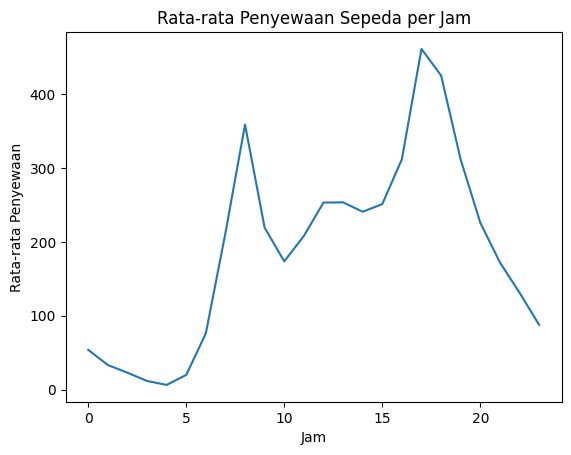

/tmp/ipykernel_4783/1007429521.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  workday_pattern = hour_df.groupby('workingday')['total_count'].mean()


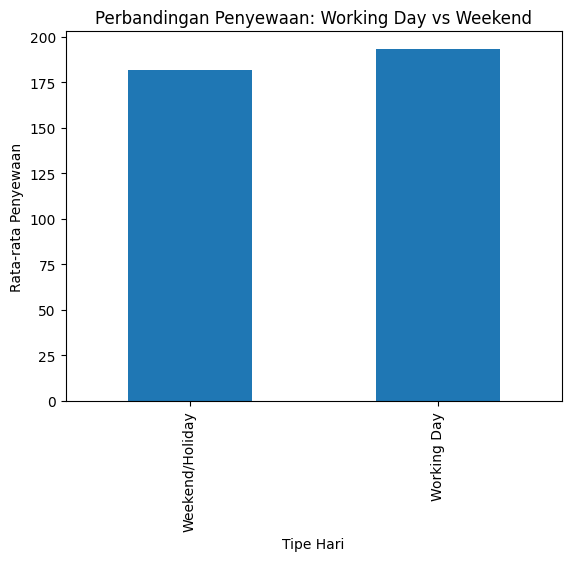

/tmp/ipykernel_4783/1007429521.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_pattern = hour_df.groupby('season')['total_count'].mean()


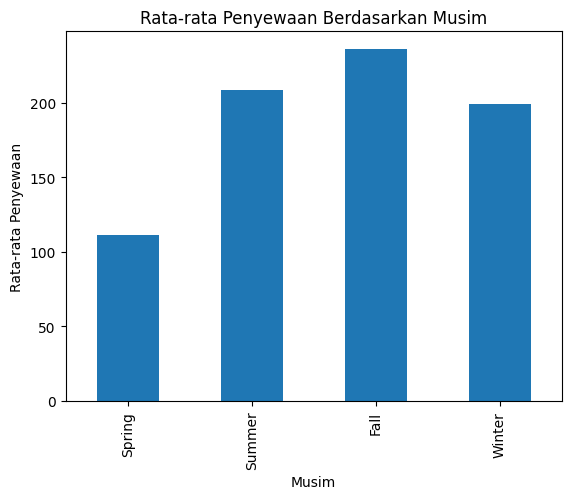

In [15]:
# pola per jam
hourly_pattern = hour_df.groupby('hr')['total_count'].mean()

plt.figure()
hourly_pattern.plot()
plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

# Working Day vs Weekend
workday_pattern = hour_df.groupby('workingday')['total_count'].mean()

plt.figure()
workday_pattern.index = ['Weekend/Holiday', 'Working Day']
workday_pattern.plot(kind='bar')
plt.title("Perbandingan Penyewaan: Working Day vs Weekend")
plt.xlabel("Tipe Hari")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

# berdasarkan musim
season_pattern = hour_df.groupby('season')['total_count'].mean()

plt.figure()
season_pattern.index = ['Spring', 'Summer', 'Fall', 'Winter']
season_pattern.plot(kind='bar')
plt.title("Rata-rata Penyewaan Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca (weathersit, suhu, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda?

/tmp/ipykernel_4783/2223886162.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_pattern = hour_df.groupby('weathersit')['total_count'].mean()


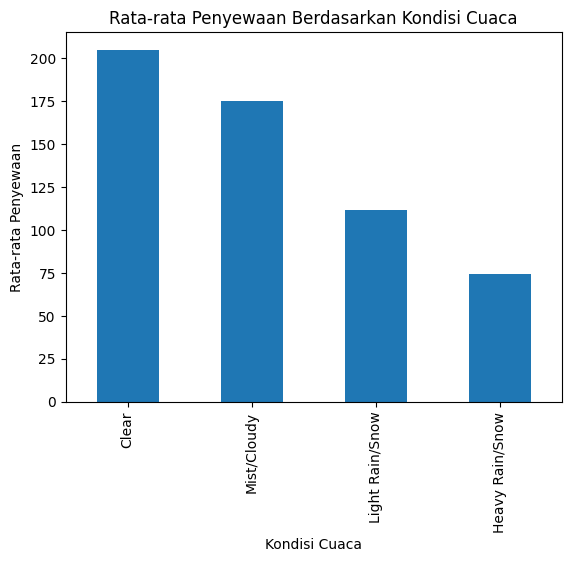

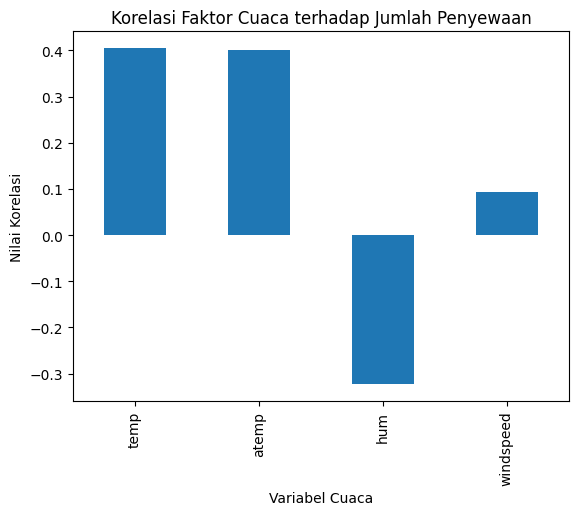

In [16]:
# kondisi cuaca
weather_pattern = hour_df.groupby('weathersit')['total_count'].mean()

plt.figure()
weather_pattern.index = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow']
weather_pattern.plot(kind='bar')
plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

# korelasi faktor cuaca
corr_values = hour_df[['temp', 'atemp', 'hum', 'windspeed', 'total_count']].corr()['total_count']

plt.figure()
corr_values.drop('total_count').plot(kind='bar')
plt.title("Korelasi Faktor Cuaca terhadap Jumlah Penyewaan")
plt.xlabel("Variabel Cuaca")
plt.ylabel("Nilai Korelasi")
plt.show()

**Insight:**
- Pola penyewaan per jam menunjukkan dua puncak utama, yaitu sekitar pukul 08.00 dan pukul 17.00–18.00, yang mengindikasikan pola penggunaan untuk aktivitas berangkat dan pulang kerja (commuting behavior), sementara penyewaan paling rendah terjadi pada dini hari (sekitar pukul 03.00–05.00).
- Rata-rata penyewaan pada working day lebih tinggi dibandingkan weekend/holiday, yang memperkuat indikasi bahwa sepeda lebih banyak digunakan sebagai sarana transportasi rutin dibandingkan untuk rekreasi.
- Berdasarkan musim, penyewaan tertinggi terjadi pada Fall, diikuti oleh Summer dan Winter, sedangkan Spring memiliki rata-rata terendah, menunjukkan bahwa faktor kenyamanan cuaca musiman sangat memengaruhi tingkat permintaan.
- Secara keseluruhan, pola waktu (jam sibuk dan hari kerja) serta musim merupakan faktor utama yang memengaruhi fluktuasi jumlah penyewaan sepeda.

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_4783/3057053953.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_casual_registered = hour_df.groupby('hr')[['casual', 'registered', 'total_count']].mean().reset_index()


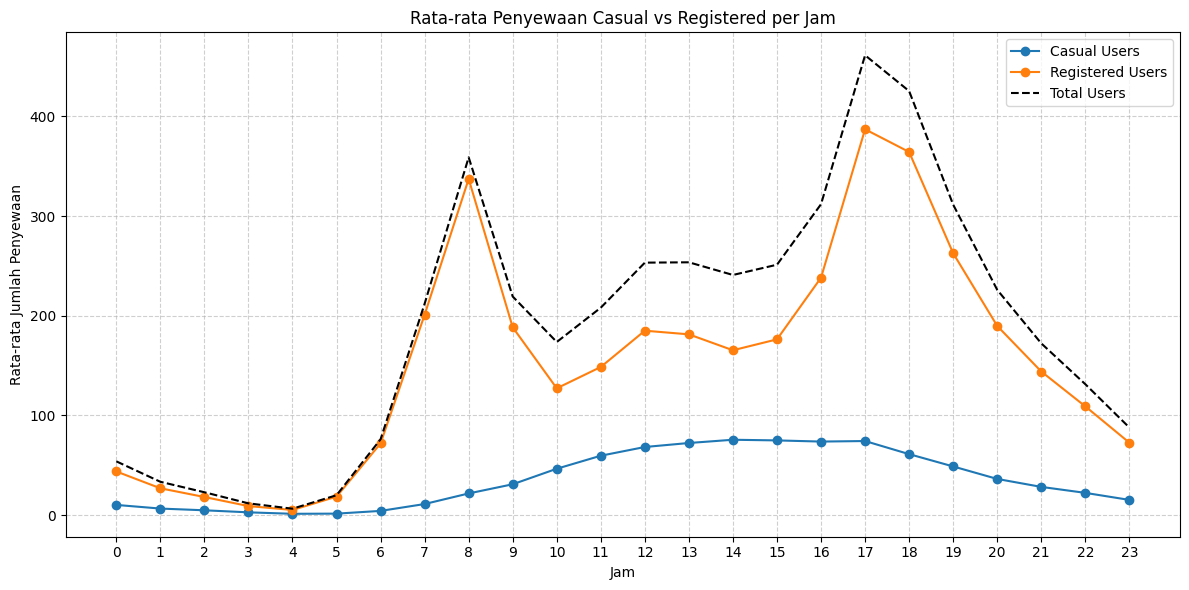

/tmp/ipykernel_4783/3057053953.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_casual_registered = hour_df.groupby('season')[['casual', 'registered', 'total_count']].mean().reset_index()


<Figure size 1000x600 with 0 Axes>

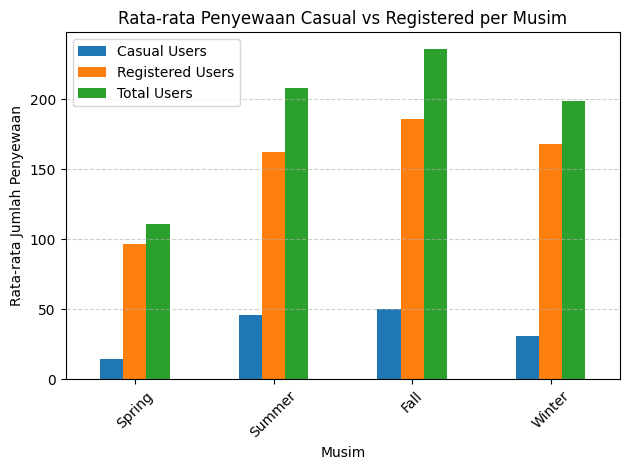

Insight:
- Pengguna terdaftar (registered) secara konsisten menyewa sepeda lebih banyak dibandingkan pengguna kasual (casual) di setiap jam dan musim.
- Pola puncak penyewaan untuk pengguna terdaftar terjadi pada jam-jam sibuk pagi (sekitar 08:00) dan sore (sekitar 17:00-18:00), mengindikasikan penggunaan untuk komuter.
- Pengguna kasual memiliki pola yang lebih datar namun cenderung meningkat pada siang hingga sore hari, kemungkinan untuk rekreasi.
- Baik pengguna kasual maupun terdaftar menunjukkan puncak penyewaan tertinggi pada musim gugur (Fall) dan musim panas (Summer), dengan pengguna kasual memiliki peningkatan yang lebih signifikan secara proporsional di musim-musim tersebut.
- Musim semi (Spring) memiliki rata-rata penyewaan terendah untuk kedua jenis pengguna.


In [17]:

# Analisis Casual vs Registered User per Jam
hourly_casual_registered = hour_df.groupby('hr')[['casual', 'registered', 'total_count']].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(hourly_casual_registered['hr'], hourly_casual_registered['casual'], label='Casual Users', marker='o')
plt.plot(hourly_casual_registered['hr'], hourly_casual_registered['registered'], label='Registered Users', marker='o')
plt.plot(hourly_casual_registered['hr'], hourly_casual_registered['total_count'], label='Total Users', linestyle='--', color='black')
plt.title('Rata-rata Penyewaan Casual vs Registered per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(hourly_casual_registered['hr'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Analisis Casual vs Registered User per Musim
seasonal_casual_registered = hour_df.groupby('season')[['casual', 'registered', 'total_count']].mean().reset_index()
seasonal_casual_registered['season'] = seasonal_casual_registered['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

plt.figure(figsize=(10, 6))
seasonal_casual_registered.set_index('season')[['casual', 'registered', 'total_count']].plot(kind='bar')
plt.title('Rata-rata Penyewaan Casual vs Registered per Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(['Casual Users', 'Registered Users', 'Total Users'])
plt.tight_layout()
plt.show()

print("Insight:")
print("- Pengguna terdaftar (registered) secara konsisten menyewa sepeda lebih banyak dibandingkan pengguna kasual (casual) di setiap jam dan musim.")
print("- Pola puncak penyewaan untuk pengguna terdaftar terjadi pada jam-jam sibuk pagi (sekitar 08:00) dan sore (sekitar 17:00-18:00), mengindikasikan penggunaan untuk komuter.")
print("- Pengguna kasual memiliki pola yang lebih datar namun cenderung meningkat pada siang hingga sore hari, kemungkinan untuk rekreasi.")
print("- Baik pengguna kasual maupun terdaftar menunjukkan puncak penyewaan tertinggi pada musim gugur (Fall) dan musim panas (Summer), dengan pengguna kasual memiliki peningkatan yang lebih signifikan secara proporsional di musim-musim tersebut.")
print("- Musim semi (Spring) memiliki rata-rata penyewaan terendah untuk kedua jenis pengguna.")

In [18]:
# Load data
day_df = pd.read_csv("day.csv")

# Konversi tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# kolom yang dibutuhkan untuk dashboard
main_df = day_df[[
    'dteday',
    'yr',
    'season',
    'workingday',
    'cnt'
]]

# Simpan
main_df.to_csv("main_data.csv", index=False)

## Conclusion

- pertanyaan 1 : Penyewaan sepeda menunjukkan pola commuting yang kuat dengan dua puncak utama pada pagi (sekitar pukul 08.00) dan sore (sekitar pukul 17.00–18.00), serta rata-rata penggunaan lebih tinggi pada hari kerja dibandingkan akhir pekan, sehingga sepeda lebih banyak dimanfaatkan sebagai sarana transportasi rutin daripada rekreasi.
- pertanyaan 2 : Kondisi cuaca dan faktor lingkungan berpengaruh signifikan terhadap jumlah penyewaan, di mana cuaca cerah dan suhu yang lebih hangat meningkatkan permintaan, sementara kelembapan tinggi dan cuaca buruk menurunkan jumlah penyewaan sepeda.